# 06 — Long-Stay Pareto

4.2% of patients stay >7 days. They consume 23.7% of bed-days,
10.2% of cost, and 50.1% of all deaths.

**Sources FINDINGS.md**: Section 3c (Long-Stay Pareto)

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()
long_stay = recent[recent["DIAS_PERM"] > 7]
normal = recent[recent["DIAS_PERM"] <= 7]

print(f"Long-stay (>7d): {len(long_stay):,} ({len(long_stay)/len(recent)*100:.1f}%)")
print(f"Normal (<=7d):   {len(normal):,}\n")
print(f"Long-stay consumes:")
print(f"  Bed-days: {long_stay['DIAS_PERM'].sum():,.0f} ({long_stay['DIAS_PERM'].sum()/recent['DIAS_PERM'].sum()*100:.1f}%)")
print(f"  Cost: R$ {long_stay['VAL_TOT'].sum():,.0f} ({long_stay['VAL_TOT'].sum()/recent['VAL_TOT'].sum()*100:.1f}%)")
print(f"  Deaths: {long_stay['MORTE'].sum():.0f} ({long_stay['MORTE'].sum()/max(recent['MORTE'].sum(),1)*100:.1f}%)")

Long-stay (>7d): 4,531 (4.2%)
Normal (<=7d):   104,166

Long-stay consumes:
  Bed-days: 58,254 (23.7%)
  Cost: R$ 11,257,933 (10.2%)
  Deaths: 176 (50.1%)


## Demographics: who stays >7 days?

In [2]:
print("\nDemographic comparison:")
for label, col, fmt in [
    ("Avg age", "age", ".1f"),
    ("Male %", "is_male", ".1f"),
    ("ER %", "is_emergency", ".1f"),
    ("Mortality %", "MORTE", ".2f"),
]:
    ls_val = long_stay[col].mean() * (100 if "%" in label else 1)
    n_val = normal[col].mean() * (100 if "%" in label else 1)
    print(f"  {label:<15} Long-stay: {ls_val:{fmt}}  Normal: {n_val:{fmt}}")

print(f"  {'Avg LOS':<15} {long_stay['DIAS_PERM'].mean():.1f}d  Max: {long_stay['DIAS_PERM'].max():.0f}d")


Demographic comparison:
  Avg age         Long-stay: 51.4  Normal: 47.7
  Male %          Long-stay: 39.0  Normal: 47.2
  ER %            Long-stay: 78.3  Normal: 50.7
  Mortality %     Long-stay: 3.88  Normal: 0.17
  Avg LOS         12.9d  Max: 97d


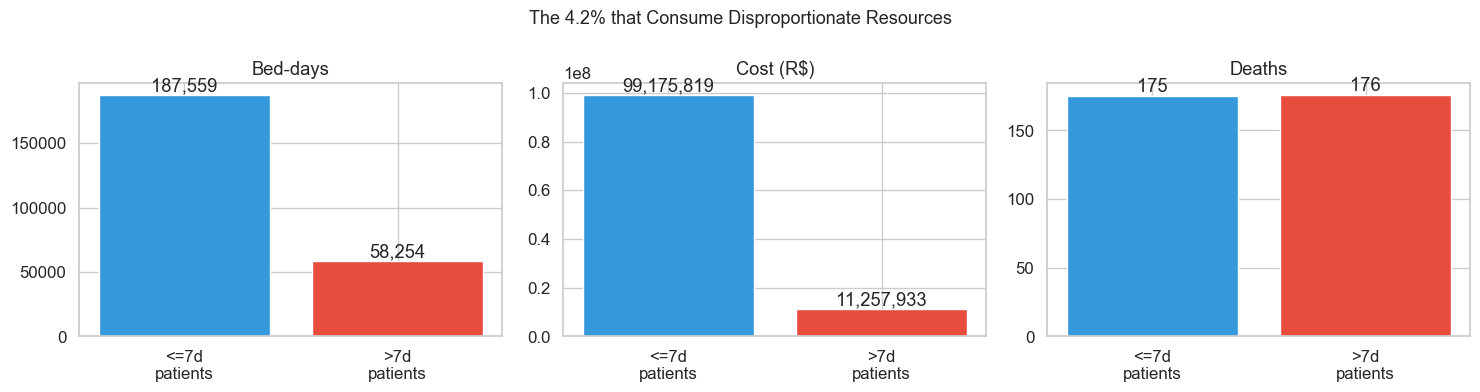

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = ["<=7d\npatients", ">7d\npatients"]
for ax, metric, title in zip(axes, ["DIAS_PERM", "VAL_TOT", "MORTE"],
                               ["Bed-days", "Cost (R$)", "Deaths"]):
    vals = [normal[metric].sum(), long_stay[metric].sum()]
    bars = ax.bar(labels, vals, color=["#3498db", "#e74c3c"])
    ax.bar_label(bars, fmt=lambda x: f"{x:,.0f}")
    ax.set_title(title)

plt.suptitle("The 4.2% that Consume Disproportionate Resources", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / "06_long_stay_impact.png", dpi=150, bbox_inches="tight")
plt.show()

## Which hospitals create the most long-stays?

In [4]:
ls_hosps = long_stay.groupby("CNES").agg(
    n_longstay=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    city=("MUNIC_MOV", "first"),
    mortality=("MORTE", "mean"),
)
total_by_hosp = recent.groupby("CNES").size().rename("n_total")
ls_hosps = ls_hosps.join(total_by_hosp)
ls_hosps["pct_longstay"] = ls_hosps["n_longstay"] / ls_hosps["n_total"] * 100

print("Top 10 hospitals by long-stay count:\n")
for cnes, r in ls_hosps.sort_values("n_longstay", ascending=False).head(10).iterrows():
    print(f"  CNES {cnes} ({city_name(r['city'])}): {r['n_longstay']:.0f} long-stays "
          f"({r['pct_longstay']:.0f}% of patients), avg {r['avg_los']:.1f}d, "
          f"mortality {r['mortality']*100:.1f}%")

Top 10 hospitals by long-stay count:

  CNES 2688689 (São Paulo): 323 long-stays (24% of patients), avg 12.3d, mortality 1.2%
  CNES 2081695 (Sorocaba): 210 long-stays (8% of patients), avg 13.9d, mortality 5.2%
  CNES 2077477 (São Paulo): 207 long-stays (12% of patients), avg 10.7d, mortality 1.9%
  CNES 9465464 (São Paulo): 174 long-stays (7% of patients), avg 12.7d, mortality 2.9%
  CNES 2755130 (Pres. Prudente): 173 long-stays (5% of patients), avg 11.9d, mortality 0.6%
  CNES 2748223 (350750): 120 long-stays (13% of patients), avg 11.5d, mortality 1.7%
  CNES 9425802 (Piracicaba): 81 long-stays (2% of patients), avg 11.6d, mortality 4.9%
  CNES 5718368 (São Paulo): 80 long-stays (4% of patients), avg 13.6d, mortality 10.0%
  CNES 2077523 (São Paulo): 73 long-stays (8% of patients), avg 13.2d, mortality 0.0%
  CNES 3126838 (Taubaté): 72 long-stays (3% of patients), avg 14.0d, mortality 2.8%


## CNES 2688689 — the worst offender

In [5]:
worst = recent[recent["CNES"] == "2688689"]
print(f"\nCNES 2688689 (São Paulo):")
print(f"  Total patients: {len(worst):,}")
print(f"  Long-stays: {(worst['DIAS_PERM'] > 7).sum()} ({(worst['DIAS_PERM'] > 7).mean()*100:.0f}%)")
print(f"  Avg LOS: {worst['DIAS_PERM'].mean():.1f}d")
print(f"\n  Procedures:")
for proc, n in worst["proc_name"].value_counts().head(5).items():
    los = worst[worst["proc_name"] == proc]["DIAS_PERM"].mean()
    print(f"    {proc}: {n} patients, LOS {los:.1f}d")


CNES 2688689 (São Paulo):
  Total patients: 1,351
  Long-stays: 323 (24%)
  Avg LOS: 4.9d

  Procedures:
    Ureteroscopy (modern): 354 patients, LOS 5.3d
    Open Ureterolithotomy: 296 patients, LOS 6.4d
    Clinical Management: 237 patients, LOS 4.5d
    Diagnostic Imaging (Urography): 164 patients, LOS 3.4d
    Surgical Management: 108 patients, LOS 5.1d


## Extreme stays (>30 days)

In [6]:
extreme = recent[recent["DIAS_PERM"] > 30]
print(f"\nExtreme stays (>30 days): {len(extreme)}")
print(f"  Avg LOS: {extreme['DIAS_PERM'].mean():.0f}d | Max: {extreme['DIAS_PERM'].max():.0f}d")
print(f"  Mortality: {extreme['MORTE'].mean()*100:.1f}%")
print(f"  Bed-days: {extreme['DIAS_PERM'].sum():,.0f}")
print(f"  Cost: R$ {extreme['VAL_TOT'].sum():,.0f}")


Extreme stays (>30 days): 143
  Avg LOS: 43d | Max: 97d
  Mortality: 11.9%
  Bed-days: 6,175
  Cost: R$ 1,412,511


## Save metrics

In [7]:
metrics = {
    "pct_patients_gt7d": round(len(long_stay) / len(recent) * 100, 1),
    "pct_bed_days_gt7d": round(long_stay["DIAS_PERM"].sum() / recent["DIAS_PERM"].sum() * 100, 1),
    "pct_cost_gt7d": round(long_stay["VAL_TOT"].sum() / recent["VAL_TOT"].sum() * 100, 1),
    "pct_deaths_gt7d": round(long_stay["MORTE"].sum() / max(recent["MORTE"].sum(), 1) * 100, 1),
    "n_extreme_gt30d": len(extreme),
    "worst_hospital_cnes": "2688689",
    "worst_hospital_pct_longstay": round((worst["DIAS_PERM"] > 7).mean() * 100, 0),
}
with open(METRICS_DIR / "long_stay_pareto.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved long_stay_pareto.json")

Saved long_stay_pareto.json
